# Curvas de aprendizaje

Marlon Solano C.

## Cómo enfrentar el problema del sesgo alto?

* Incrementar la complejidad del modelo
* Cambiar a un modelo de ML más complejo
* Agregar nuevas variables
* Alguna técnica de regularización 
* Modificar la partición de los datos del conjunto inicial

## Como me enfrento al problema de la varianza alta (high variance)?

* Preprocesamiento 
* Regularización
* Early stopping
* Mayor cantidad de épocas
* Análisis de erroes
* Reducción de dimensionalidad
* Simplificar el modelo
* Agregar más datos al problema

## Caso de las tarjetas de crédito con curvas de aprendizaje

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

In [2]:
import ssl
import urllib.request
import pandas as pd

# 1. Configurar para ignorar la verificación de certificados SSL
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

# 2. Descargar y leer el archivo directamente desde la web
mypath = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"

with urllib.request.urlopen(mypath, context=ctx) as response:
    data = pd.read_csv(response, sep=" ", header=None)

# 3. Asignar los nombres correctos a las columnas
data.columns = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','class']

# 4. Verificar que cargó correctamente
print("Dimensiones del dataset:", data.shape)
print(data.head())

# 5. Algunos ajustes previos con datos categóricos con niveles de muy baja frecuencia con fines didácticos:
data['A4'] = data['A4'].map({2:2, 1:0, 3:0})
data['A5'] = data['A5'].map({1:1,2:0,3:3,4:4,5:0,6:6,7:7,8:8,9:9,10:0,11:11,12:0,13:13,14:14})
data['A6'] = data['A6'].map({1:1,2:0,3:0,4:4,5:5,7:0,8:8,9:0})

# A partir de aquí ya puedes definir tus datos de entrada (X) y salida (Y) en la siguiente celda...

Dimensiones del dataset: (690, 15)
   A1     A2     A3  A4  A5  A6     A7  A8  A9  A10  A11  A12  A13   A14  \
0   1  22.08  11.46   2   4   4  1.585   0   0    0    1    2  100  1213   
1   0  22.67   7.00   2   8   4  0.165   0   0    0    0    2  160     1   
2   0  29.58   1.75   1   4   4  1.250   0   0    0    1    2  280     1   
3   0  21.67  11.50   1   5   3  0.000   1   1   11    1    2    0     1   
4   1  20.17   8.17   2   6   4  1.960   1   1   14    0    2   60   159   

   class  
0      0  
1      0  
2      0  
3      1  
4      1  


In [3]:
# Transformaciones a factores numéricos de entrada:
num_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='median')),
                                 ('escalaNum', MinMaxScaler(feature_range=(1,2)))])   
num_pipeline_nombres = ['A2','A3','A7','A10','A13','A14']

# Transformaciones a factores categóricos de entrada:
catImp_pipeline = Pipeline(steps = [('impModa', SimpleImputer(strategy='most_frequent'))])  
catImp_pipeline_nombres = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

# Transformaciones one-hot-encoder en algunas de las categóricas:
catOHE_pipeline = Pipeline(steps = [('OneHotE', OneHotEncoder(drop='first'))])
catOHE_pipeline_nombres = [ 'A4','A5','A6','A12']

# Conjuntamos las transformaciones numéricas y categóricas que se estarán aplicando a los datos de entrada:
columnasTransformer = ColumnTransformer(transformers = [('numpipe', num_pipeline, num_pipeline_nombres),
                                                        ('catimp', catImp_pipeline, catImp_pipeline_nombres),
                                                        ('catohe', catOHE_pipeline, catOHE_pipeline_nombres)],
                                        remainder='passthrough')

In [4]:
from sklearn.model_selection import validation_curve

In [5]:
from sklearn.model_selection import train_test_split

# 1. Definir los datos de entrada y salida a partir del DataFrame cargado
X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

# 2. Realizar la partición de entrenamiento/validación y prueba
Xtv, Xtest, ytv, ytest = train_test_split(
    X, Y, test_size=0.2, random_state=1, stratify=Y
)

# 3. Verificar las dimensiones
print('Dimensiones de Xtv:', Xtv.shape)

Dimensiones de Xtv: (552, 14)


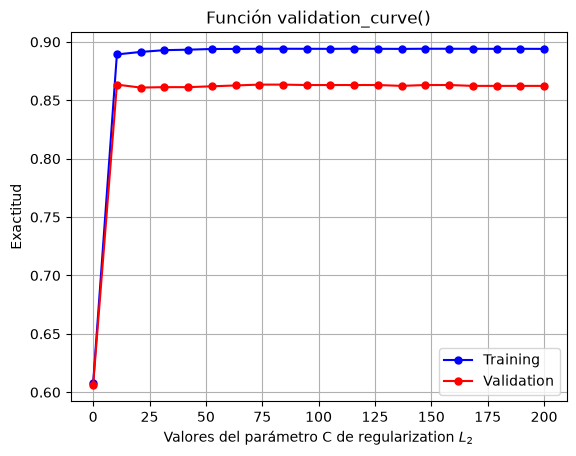

In [6]:
import warnings
warnings.filterwarnings('ignore')

delta_C = np.linspace(.0001, 200., 20)

modelo = LogisticRegression(penalty='l2', 
                            max_iter=10000,
                            solver='liblinear',
                            random_state=1)

Xx = columnasTransformer.fit_transform(Xtv)

cvLC = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=11)

train_scores, valid_scores = validation_curve(modelo, 
                                              Xx, 
                                              np.ravel(ytv), 
                                              param_name="C", 
                                              param_range=delta_C,
                                              cv=cvLC,
                                              scoring='accuracy')


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)


# Curva de entrenamiento con la métrica de exactitud (accuracy):
plt.plot(delta_C, train_mean, color='blue', marker='o', markersize=5, label='Training')

# Curva de validación:
plt.plot(delta_C, valid_mean, color='red', marker='o', markersize=5, label='Validation')

plt.title('Función validation_curve()')
plt.xlabel('Valores del parámetro C de regularization $L_2$')
plt.ylabel('Exactitud')
plt.grid()
plt.legend(loc='lower right')
plt.show()

In [11]:
# Salvo el primer valor, el modelo se mantiene casi constante tanto para
# los datos de entrenamiento como de validación:

print('Valor promedio de los resultados con los conjuntos de entrenamiento: %.3f' % train_mean[1:20].mean())
print('Valor promedio de los resultados con los conjuntos de validación: %.3f' % valid_mean[1:20].mean())

Valor promedio de los resultados con los conjuntos de entrenamiento: 0.894
Valor promedio de los resultados con los conjuntos de validación: 0.863
